In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Suppress FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from glob import glob
from tqdm import tqdm

/tmp/ipykernel_2783481/2590474423.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
def split_into_files(lines, num_files):
    # Calculate the number of lines per file
    lines_per_file = len(lines) // num_files
    remainder = len(lines) % num_files
    
    # Split lines into chunks for each file
    chunks = []
    start = 0
    for i in range(num_files):
        # Allocate the remainder evenly
        end = start + lines_per_file + (1 if i < remainder else 0)
        chunks.append(lines[start:end])
        start = end
    
    # Write each chunk to a separate file
    for i, chunk in enumerate(chunks):
        with open(f'sh{i+1}.sh', 'w') as f:
            f.write('\n'.join(chunk))

In [4]:
num_epoch = 2500
num_epoch_pretrain = 500
num_trials = 10
view_list = "1,2,3"
lr_e_pretrain = 1e-3
lr_e = 5e-4
lr_c = 1e-3
save_path = "result_sof"

# Grid search

In [5]:
num_epoch = 2500
num_epoch_pretrain = 500
num_trials = 10
lr_e_pretrain = 1e-3
lr_e = 5e-4
lr_c = 1e-3
save_path = "result_sof"

commands = []
count = 0
for view_list in ["1", "2", "3", "1,2", "1,3", "2,3", "1,2,3"]:
    for data_folder in ["SOF"]:
        for num_trials in [2, 5, 10]:
            #for adj_param in range(2, 5, 1):
            for adj_param in [2, 5, 10]:
                command = f"python main_uncertainty.py --view_list={view_list} --data_folder={data_folder} --num_trials={num_trials}" \
                        f" --save_path={save_path} --num_epoch={num_epoch}  --num_epoch_pretrain={num_epoch_pretrain}" \
                        f" --lr_e={lr_e} --lr_c={lr_c} --exp=exp --num_adj={adj_param}"
                # print(command)
                count += 1
                commands.append(command)
print(count)

split_into_files(commands, 4)

63


In [6]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

df_performance = pd.DataFrame(columns=['data_folder', 'view_list', 'num_trials', 'adj_param', 'acc','measure1','measure2','uncertainty'])
#for data_folder in ["BRCA", "ROSMAP", "LGG", "KIPAN"]:
data_folder = "SOF"

for view_list in ["1", "2", "3", "1,2", "1,3", "2,3", "1,2,3"]:
    for num_trials in [2,5]:
            for adj_param in [2,5]:
                # print(f"{save_path}/{data_folder}/{view_list}/n_trials{num_trials}_adj{adj_param}.csv")
                df = pd.read_csv(f"{save_path}/{data_folder}/{view_list}/n_trials{num_trials}_adj{adj_param}.csv")
                pred = df['pred'].to_numpy()
                label = df['label'].to_numpy()
                uncertainty = np.mean(df['std'].to_numpy())
                acc = accuracy_score(label, pred)
                measure1 = f1_score(label, pred)
                measure2 = roc_auc_score(label, pred)
                
                df_performance.loc[df_performance.shape[0]] = pd.Series({"data_folder": data_folder, "view_list": view_list.replace(",","-"), 
                                                                "acc": acc, "measure1": measure1, "measure2": measure2, "uncertainty": uncertainty, 
                                                                "num_trials": num_trials, "adj_param": adj_param})
df_performance.to_csv(f"{save_path}/performance.csv", index=False)
df_performance.head(5)

,data_folder,view_list,num_trials,adj_param,acc,measure1,measure2,uncertainty
0,SOF,1,2,2,0.849558,0.019231,0.504854,0.009696
1,SOF,1,2,5,0.848083,0.0,0.5,0.004578
2,SOF,1,5,2,0.849558,0.019231,0.504854,0.013895
3,SOF,1,5,5,0.848083,0.0,0.5,0.011381
4,SOF,2,2,2,0.848083,0.0,0.5,0.001276


# Select best and perform staged prediction

In [7]:
result_df = pd.DataFrame(columns=['data_folder', 'view_list', 'num_trials', 'adj_param', 'acc','measure1','measure2','uncertainty'])
for dataset in ["SOF"]:
    df_performance_sub = df_performance[df_performance['data_folder']==dataset]
    for view_list in ["1","2","3"]:
        single_modality_df = df_performance_sub[df_performance_sub['view_list'].apply(lambda x: '-' not in x)]
        single_modality_df = single_modality_df[single_modality_df['view_list']==view_list]
        best_single_modality = single_modality_df.loc[single_modality_df['acc'].idxmax()]
        result_df = pd.concat([result_df, best_single_modality.to_frame().T])

    for view_list in ["1-2", "1-3", "2-3"]:
        two_modality_df = df_performance_sub[df_performance_sub['view_list'].apply(lambda x: '-' in x and len(x.split('-')) == 2)]
        two_modality_df = two_modality_df[two_modality_df['view_list']==view_list]
        best_two_modality = two_modality_df.loc[two_modality_df['acc'].idxmax()]
        result_df = pd.concat([result_df, best_two_modality.to_frame().T])

    # Step 3: Keep the row with the view list of 1-2-3 if it exists
    three_modality_df = df_performance_sub[df_performance_sub['view_list'] == '1-2-3']
    best_modality_df = three_modality_df.loc[three_modality_df['acc'].idxmax()]

    # Combine all selected rows into a new dataframe
    result_df = pd.concat([result_df, best_modality_df.to_frame().T])

result_df.to_csv(f"{save_path}/best_performance_for_each_view.csv", index=False)
result_df

,data_folder,view_list,num_trials,adj_param,acc,measure1,measure2,uncertainty
0,SOF,1,2,2,0.849558,0.019231,0.504854,0.009696
4,SOF,2,2,2,0.848083,0.0,0.5,0.001276
11,SOF,3,5,5,0.849558,0.072727,0.516809,0.027131
12,SOF,1-2,2,2,0.849558,0.019231,0.504854,0.208639
17,SOF,1-3,2,5,0.849558,0.055556,0.512824,0.012801
20,SOF,2-3,2,2,0.848083,0.0,0.5,0.194644
24,SOF,1-2-3,2,2,0.848083,0.0,0.5,0.052862


# staged

In [8]:
result_df = pd.DataFrame(columns=['data_folder', 'view_list', 'num_trials', 'adj_param', 'acc','measure1','measure2','uncertainty'])
for dataset in ["SOF"]:
    df_performance_sub = df_performance[df_performance['data_folder']==dataset]
    single_modality_df = df_performance_sub[df_performance_sub['view_list'].apply(lambda x: '-' not in x)]
    best_single_modality = single_modality_df.loc[single_modality_df['acc'].idxmax()]

    # Step 2: Select the best two-modality view containing the best single modality
    best_single_view = best_single_modality['view_list']
    two_modality_df = df_performance_sub[df_performance_sub['view_list'].apply(lambda x: '-' in x and len(x.split('-')) == 2 and best_single_view in x)]
    best_two_modality = two_modality_df.loc[two_modality_df['acc'].idxmax()]

    # Step 3: Keep the row with the view list of 1-2-3 if it exists
    three_modality_df = df_performance_sub[df_performance_sub['view_list'] == '1-2-3']
    best_modality_df = three_modality_df.loc[three_modality_df['acc'].idxmax()]

    # Combine all selected rows into a new dataframe
    result_df_sub = pd.concat([best_single_modality.to_frame().T, best_two_modality.to_frame().T, best_modality_df.to_frame().T])
    result_df = pd.concat([result_df_sub, result_df])

result_df.to_csv(f"{save_path}/best_performance_for_stage.csv", index=False)
result_df

,data_folder,view_list,num_trials,adj_param,acc,measure1,measure2,uncertainty
0,SOF,1,2,2,0.849558,0.019231,0.504854,0.009696
12,SOF,1-2,2,2,0.849558,0.019231,0.504854,0.208639
24,SOF,1-2-3,2,2,0.848083,0.0,0.5,0.052862


In [22]:
view_lists = result_df[result_df['data_folder']==data_folder]['view_list'].to_list()
num_trails = result_df[result_df['data_folder']==data_folder]['num_trials'].to_list() 
adj_param = result_df[result_df['data_folder']==data_folder]['adj_param'].to_list()

converted_view_list = [view.replace('-', ',') for view in view_lists]
print(converted_view_list)
print(num_trails)
print(adj_param)

['1', '1,2', '1,2,3']
[5, 10, 5]
[2, 2, 2]


In [23]:
df_staged = pd.DataFrame(columns=["data_folder", "acc",  'num_trials', 'adj_param', "measure1", "measure2", "t1", "t2"])

for data_folder in ["SOF"]:
    view_lists = result_df[result_df['data_folder']==data_folder]['view_list'].to_list()
    converted_view_list = [view.replace('-', ',') for view in view_lists]
    num_trails = result_df[result_df['data_folder']==data_folder]['num_trials'].to_list() 
    adj_param = result_df[result_df['data_folder']==data_folder]['adj_param'].to_list()

    df_uni = pd.read_csv(f"{save_path}/{data_folder}/{converted_view_list[0]}/n_trials{num_trails[0]}_adj{adj_param[0]}.csv").copy()
    df_bi = pd.read_csv(f"{save_path}/{data_folder}/{converted_view_list[1]}/n_trials{num_trails[1]}_adj{adj_param[1]}.csv").copy()
    df_tri = pd.read_csv(f"{save_path}/{data_folder}/{converted_view_list[2]}/n_trials{num_trails[2]}_adj{adj_param[2]}.csv").copy()
    threshold_range_uni = np.linspace(df_uni['std'].min(), df_uni['std'].max(), 50)
    threshold_range_bi = np.linspace(df_bi['std'].min(), df_bi['std'].max(), 50)

    best_auc = 0.
    best_threshold_t1 = 0
    best_threshold_t2 = 0

    for t1 in tqdm(threshold_range_uni):
        for t2 in threshold_range_bi:
            df_classified_confident_stage = pd.DataFrame(columns=["patient_id", "stage", "std", "pred", "label"])
            move_forward = True

            # single view
            df_uni['confident'] = df_uni['std'] <= t1
            df_uni_confident = df_uni[df_uni['confident']]
            df_uni_confident = df_uni_confident.copy()
            df_uni_confident.loc[:, "stage"] = view_lists[0]

            df_uni_confident = df_uni_confident[["patient_id", "stage", "std", "pred", "label"]]
            df_classified_confident_stage = pd.concat([df_classified_confident_stage, df_uni_confident], ignore_index=True)

            if df_classified_confident_stage.shape[0] != df_uni.shape[0]:
                # Unconfident predictions - use 2 views
                df_uni_unconfident = df_uni[~df_uni['confident']]
                df_bi_sub = df_bi[df_bi['patient_id'].isin(df_uni_unconfident['patient_id'])]
                df_bi_sub = df_bi_sub.copy()
                df_bi_sub.loc[:, 'confident'] = df_bi_sub['std'] <= t2
                df_bi_confident = df_bi_sub[df_bi_sub['confident']]
                
                if df_bi_confident.shape[0] == 0:
                    # t2 is too small, no subjects in bi-view model is confident
                    continue
                
                df_bi_confident = df_bi_confident.copy()
                df_bi_confident.loc[:, "stage"] = view_lists[1]
                df_bi_confident = df_bi_confident[["patient_id", "stage", "std", "pred", "label"]]
                df_classified_confident_stage = pd.concat([df_classified_confident_stage, df_bi_confident], ignore_index=True)

                if df_classified_confident_stage.shape[0] != df_uni.shape[0]:
                    # Unconfident predictions - use 3 views
                    df_bi_unconfident = df_bi_sub[~df_bi_sub['confident']]
                    df_tri_sub = df_tri[df_tri['patient_id'].isin(df_bi_unconfident['patient_id'])]
                    df_tri_sub = df_tri_sub.copy()
                    df_tri_sub.loc[:, 'stage'] = view_lists[2]
                    df_tri_sub = df_tri_sub[["patient_id", "stage", "std", "pred", "label"]]
                    df_classified_confident_stage = pd.concat([df_classified_confident_stage, df_tri_sub], ignore_index=True)

            assert df_classified_confident_stage.shape[0] == df_uni.shape[0]
            total_accuracy = accuracy_score(df_classified_confident_stage['label'].to_list(), df_classified_confident_stage['pred'].to_list())
            total_f1 = f1_score(df_classified_confident_stage['label'].to_list(), df_classified_confident_stage['pred'].to_list())
            total_auc = roc_auc_score(df_classified_confident_stage['label'].to_list(), df_classified_confident_stage['pred'].to_list())
            # Update best threshold if this one is better
            if total_auc > best_auc:
                best_auc = total_auc
                best_threshold_t1 = t1
                best_threshold_t2 = t2
                df_classified_confident_stage.to_csv(f"{save_path}/{data_folder}/staged_results.csv", index=False)
            # print(f"acc = {total_accuracy}, t1 = {t1}, t2 = {t2}")

    if data_folder in ["ROSMAP", "LGG"]:
        acc = accuracy_score(df_classified_confident_stage['label'].to_list(), df_classified_confident_stage['pred'].to_list())
        measure1 = f1_score(df_classified_confident_stage['label'].to_list(), df_classified_confident_stage['pred'].to_list())
        measure2 = roc_auc_score(df_classified_confident_stage['label'].to_list(), df_classified_confident_stage['pred'].to_list())
    elif data_folder in ["KIPAN", "BRCA"]:
        acc = accuracy_score(df_classified_confident_stage['label'].to_list(), df_classified_confident_stage['pred'].to_list())
        measure1 = f1_score(df_classified_confident_stage['label'].to_list(), df_classified_confident_stage['pred'].to_list(), average='weighted')
        measure2 = f1_score(df_classified_confident_stage['label'].to_list(), df_classified_confident_stage['pred'].to_list(), average='macro')
    print(f"data_folder = {data_folder}, best_accuracy = {acc}, measure1 = {measure1}, measure2 = {measure2}, best_threshold_t1 = {best_threshold_t1}, best_threshold_t2 = {best_threshold_t2}")
    
    df_staged.loc[df_staged.shape[0]] = pd.Series({"data_folder": data_folder, "acc": acc, "measure1": measure1, "measure2": measure2, 
                                                    "t1": best_threshold_t1, "t2": best_threshold_t2})
df_staged.to_csv(f"{save_path}/staged_performance.csv", index=False)

100%|██████████| 50/50 [00:07<00:00,  6.66it/s]

data_folder = SOF, best_accuracy = 0.8716814159292036, measure1 = 0.2926829268292683, measure2 = 0.5856395103419164, best_threshold_t1 = 0.2305476642857143, best_threshold_t2 = 0.18638649857142858


# Staged percentage

In [ ]:
df_staged_percent = pd.DataFrame(columns=["data_folder", "stage1", "stage2", "stage3"])
for data_folder in ["SOF"]:
    df_classified_confident_stage = pd.read_csv(f"{save_path}/{data_folder}/staged_results.csv")
    n_subjects = df_classified_confident_stage.shape[0]
    stages = pd.unique(df_classified_confident_stage['stage'])
    stage_strings = []
    for stage in stages:
        stage_string = ""
        if stage.rfind("1")!=-1:
            stage_string += "CLI|"
        if stage.rfind("2")!=-1:
            stage_string += "DXA|"
        if stage.rfind("3")!=-1:
            stage_string += "WGS|"
        stage_string += f"{df_classified_confident_stage[df_classified_confident_stage['stage']==stage].shape[0]/n_subjects *100 : 0.2f}%"
        stage_strings.append(stage_string)
    df_staged_percent.loc[df_staged_percent.shape[0]] = pd.Series({"data_folder": data_folder, "stage1": stage_strings[0] , "stage2": stage_strings[1] , "stage3": stage_strings[2]})

df_staged_percent.to_csv(f"{save_path}/percentage.csv", index=False)
df_staged_percent

IndexError: list index out of range

# Uncertainty distribution

/tmp/ipykernel_1483772/3433222268.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_classified_confident_stage_sub['label_c'] = df_classified_confident_stage_sub['label'].map(label_map)
/tmp/ipykernel_1483772/3433222268.py:17: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_classified_confident_stage_sub, x="std", hue="label_c", ax=axes[i], palette="tab10")
/tmp/ipykernel_1483772/3433222268.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

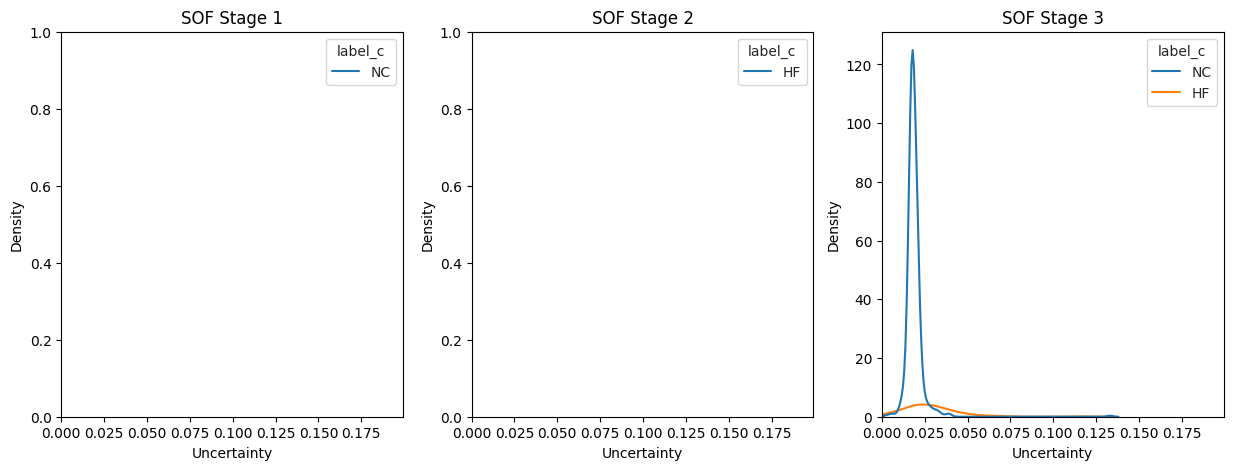

In [ ]:
fig, axes = plt.subplots(1, 3)
fig.set_figwidth(15)
fig.set_figheight(5)
sns.set_style("whitegrid")


label_map = {0: 'NC', 1: 'HF'}

for idx, data_folder in enumerate(["SOF"]):
    view_lists = result_df[result_df['data_folder']==data_folder]['view_list'].to_list()
    converted_view_list = [view.replace('-', ',') for view in view_lists]

    df_classified_confident_stage = pd.read_csv(f"{save_path}/{data_folder}/staged_results.csv")
    for i in range(3):
        df_classified_confident_stage_sub = df_classified_confident_stage[df_classified_confident_stage['stage']==view_lists[i]]
        df_classified_confident_stage_sub['label_c'] = df_classified_confident_stage_sub['label'].map(label_map)
        sns.kdeplot(df_classified_confident_stage_sub, x="std", hue="label_c", ax=axes[i], palette="tab10")
        axes[i].set_title(f"{data_folder} Stage {i+1}")
        axes[i].set_xlim(0,np.max(df_classified_confident_stage['std'])*1.5)
        axes[i].set_xlabel("Uncertainty")

plt.savefig(f"{save_path}/uncertainty_distribution.png", dpi=300)
plt.show()


# Explain Features

In [ ]:
result_df

,data_folder,view_list,num_trials,adj_param,acc,measure1,measure2,uncertainty
0,SOF,1,2,2,0.995575,0.985222,0.985437,0.000586
27,SOF,1-2,2,2,0.995575,0.985222,0.985437,0.192923
54,SOF,1-2-3,2,2,0.995575,0.985222,0.985437,0.020209


In [ ]:
import copy
from feat_importance import cal_feat_imp, summarize_imp_feat

data_folder = 'SOF'
exp_path = "exp"
num_class = 2

print(converted_view_list)

df_featimp_top_list = []
for stage in range(3):
    view_list, num_trails, adj_parameter = result_df.iloc[stage]['view_list'], result_df.iloc[stage]['num_trials'], result_df.iloc[stage]['adj_param']
    str_view_list = view_list.replace('-', ',')
    view_list = [int(x) for x in str_view_list.split(',')] 
    #print(view_list)
    
    featimp_list_list = []
    for t in range(num_trails):
        featimp_list = cal_feat_imp(data_folder, f"{exp_path}/{data_folder}_v{str_view_list}_t{num_trails}_a{adj_parameter}/trail{t}", view_list, num_class, adj_parameter)
        featimp_list_list.append(copy.deepcopy(featimp_list))

    feat_names, df_featimp_top = summarize_imp_feat(featimp_list_list, topn=30)
    df_featimp_top['omics_s'] = df_featimp_top['omics'].map({0: "CLI", 1: "DXA", 2: "WGS"})
    df_featimp_top['imp'] = df_featimp_top['imp']/num_trails
    df_featimp_top.to_csv(f"{save_path}/feat_imp_{str_view_list}.csv", index=False)
    df_featimp_top_list.append(df_featimp_top)


['1', '1,2', '1,2,3']
Rank	Feature name
1	HIPIND2	124.13793103448276
2	FOLHIP2	1.5763823423001113
3	HA_HIPFXFU	1.5763823423001113
4	RSEMITS	1.241379310344826
5	HA_SLDFXFU	0.952619966062487
6	RSTBALIC	0.952619966062487
7	ESTATUS	0.9371799248890421
8	HA_WRSTFXFU	0.9371799248890421
9	V1CLINIC	0.9249492900608549
10	RWLKSPED	0.6329805394332582
11	RQUET	0.6329805394332582
12	HA_WRSTFX	0.6329805394332582
13	HA_WLKSPED	0.6329805394332582
14	WRSTIND2	0.6329805394332582
15	HA_BMI	0.6329805394332582
16	FOLWRST	0.6329805394332582
17	FOLHUM	0.6329805394332582
18	RDRNKWK	0.620749904605071
19	V2DSNCR	0.620749904605071
20	V4BUA	0.3164902697166291
21	HA_AGE	0.3164902697166291
22	RCSENAVG	0.3164902697166291
23	RAGE2	0.3164902697166291
24	RSTBALIO	0.3164902697166291
25	RTSTAND	0.3164902697166291
26	HA_KIDNYST	0.3042596348884419
27	RGRIPAVG	0.3042596348884419
28	RHTCMS	0.3042596348884419
29	HA_HEIGHT	0.3042596348884419
30	HA_VITAL	0.3042596348884419
Rank	Feature name
1	HIPIND2	122.9263925729443
2	FOLHIP2	

In [ ]:
# Stage 1,2,3
common_feat_names = pd.merge(df_featimp_top_list[0][['feat_name']], df_featimp_top_list[1][['feat_name']], on='feat_name')
common_feat_names = pd.merge(common_feat_names, df_featimp_top_list[2][['feat_name']], on='feat_name')
common_feat_names


,feat_name
0,HIPIND2
1,HA_HIPFXFU


In [ ]:
common_feat_names = pd.merge(df_featimp_top_list[1][['feat_name']], df_featimp_top_list[2][['feat_name']], on='feat_name')
common_feat_names

,feat_name
0,HIPIND2
1,HA_HIPFXFU


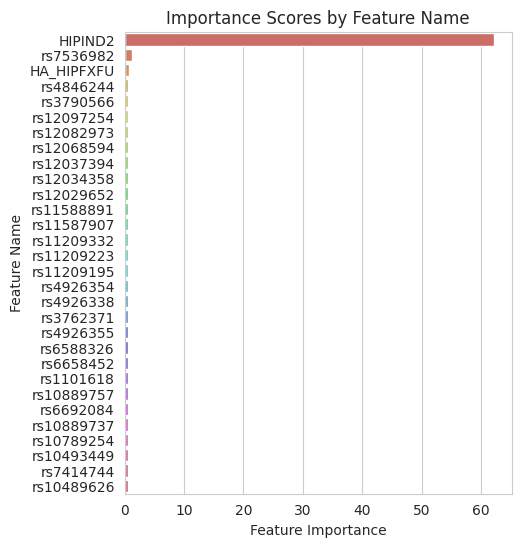

In [ ]:
plt.figure(figsize=(5, 6))
sns.barplot(data=df_featimp_top_list[2], y='feat_name', x='imp', palette="hls")

# Labels and title
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("Importance Scores by Feature Name")


plt.savefig(f"{save_path}/feat_img_vis.png", dpi=300)

plt.show()